# Progettazione di action e observation specs, basate su dati raccolti dai replay dei training preliminari

In [1]:
# pip install peppi-py ipyfilechooser pandas matplotlib
import glob, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from peppi_py import read_slippi
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt

In [2]:
available_replay_dirs = glob.glob("replays/*")
print("Available replay directories:")
for dir in available_replay_dirs:
    print(f" - {dir}")

Available replay directories:
 - replays/mario_luigi__full_action_cpu3_new_obs
 - replays/mario_luigi__full_action_cpu3_fixed
 - replays/new_spec_6_continuation_fixed
 - replays/default
 - replays/new_spec_6
 - replays/new_spec_5_continuation
 - replays/new_spec_6_continuation
 - replays/mario_luigi_cpu3_to_cpu4_v2
 - replays/run_002
 - replays/new_spec_5_continuation_fixed
 - replays/new_spec_5_continuation_no_exploration
 - replays/test_save
 - replays/third_test
 - replays/new_spec_6_continuation_no_exploration_2
 - replays/fourth_test
 - replays/multiprocessing_test_fixed_2
 - replays/mario_luigi_cpu3_to_cpu4
 - replays/new_spec_5_continuation_no_exploration_2
 - replays/diag
 - replays/new_spec_5
 - replays/new_spec_3
 - replays/mario_luigi_cpu3_to_cpu5
 - replays/multiprocessing_test_fixed
 - replays/mario_luigi__full_action_cpu3_new_obs_fixed
 - replays/mario_luigi__full_action_cpu3
 - replays/second_test
 - replays/continuation
 - replays/fifth_test
 - replays/cpu_7
 - replays/

In [3]:
dir_selector = widgets.Dropdown(
    options=available_replay_dirs,
    description='Select replay directory:',
    disabled=False,
)

display(dir_selector)

Dropdown(description='Select replay directory:', options=('replays/mario_luigi__full_action_cpu3_new_obs', 're…

In [4]:
def to_np(a):
    return a.to_numpy(zero_copy_only=False)   # zero_copy_only=False gestisce eventuali null

base_dir = dir_selector.value
paths = sorted(glob.glob(os.path.join(base_dir, "**/*.slp"), recursive=True))
print(f"Parsing {len(paths)} replay in {dir_selector.value}...")

def get_replay_info(path):

    replay = read_slippi(path)
    ports = replay.frames.ports
    info = []

    for n, port in enumerate(ports):
        info.append({})

        info[-1][f"x_position"] = to_np(port.leader.post.position.x)
        info[-1][f"y_position"] = to_np(port.leader.post.position.y)

        info[-1][f"x_velocity"] = to_np(port.leader.post.velocities.self_x_ground) + to_np(port.leader.post.velocities.self_x_air)
        info[-1][f"y_velocity"] = to_np(port.leader.post.velocities.self_y)

        info[-1][f"x_attack_velocity"] = to_np(port.leader.post.velocities.knockback_x)
        info[-1][f"y_attack_velocity"] = to_np(port.leader.post.velocities.knockback_y)

        info[-1][f"percent_damage"] = to_np(port.leader.post.percent)
        info[-1][f"stock_count"] = to_np(port.leader.post.stocks)

        info[-1][f"facing_direction"] = to_np(port.leader.post.direction)

        info[-1][f"hitstun_frames"] = to_np(port.leader.post.misc_as)
        info[-1][f"jumps_remaining"] = to_np(port.leader.post.jumps)
        info[-1]["airborne"] = to_np(port.leader.post.airborne)
        info[-1]["hurtbox_state"] = to_np(port.leader.post.hurtbox_state)


    return info, [i for i in range(len(ports))]

path = paths[8]
data, ports = get_replay_info(path)
print(f"Numero di frame nel replay {path}: {data[0]['x_position'].shape[0]}")
for port in ports:
    print(f"\nPort {port}:")
    for key, value in data[port].items():
        print(f"{key}: {value}")

Parsing 25 replay in replays/mario_luigi__full_action_cpu3_new_obs...
Numero di frame nel replay replays/mario_luigi__full_action_cpu3_new_obs/instance_1/Game_20260711T150401.slp: 8230

Port 0:
x_position: [-60.      -60.      -60.      ... 118.99165 119.19615 119.43815]
y_position: [  10.        10.        10.      ... -137.39996 -139.69997 -141.99997]
x_velocity: [0.         0.         0.         ... 0.16699985 0.20449984 0.        ]
y_velocity: [ 0.   0.   0.  ... -2.3 -2.3  0. ]
x_attack_velocity: [0. 0. 0. ... 0. 0. 0.]
y_attack_velocity: [0. 0. 0. ... 0. 0. 0.]
percent_damage: [ 0.    0.    0.   ... 39.56 39.56 39.56]
stock_count: [4 4 4 ... 1 1 0]
facing_direction: [ 1.  1.  1. ... -1. -1. -1.]
hitstun_frames: [5.6e-45 4.2e-45 2.8e-45 ... 3.1e-44 3.1e-44 8.4e-44]
jumps_remaining: [1 1 1 ... 0 0 0]
airborne: [1 1 1 ... 1 1 1]
hurtbox_state: [0 0 0 ... 0 0 0]

Port 1:
x_position: [60.      60.      60.      ... 81.72835 81.72835 81.72835]
y_position: [1.e+01 1.e+01 1.e+01 ... 1.e-

In [5]:
class FakeSession:
    def __init__(self, replay_data, ports):
        self.replay_data = replay_data
        self.ports = ports
        self.frame_count = replay_data[0]['x_position'].shape[0]
        self.current_frame = 0
    
    def step(self, target_frame=None):
        if target_frame is not None:
            self.current_frame = target_frame
        else:
            self.current_frame += 1
        if self.current_frame >= self.frame_count:
            raise StopIteration("Reached the end of the replay.")
    
    # -- proprietà per emulare quelle di session --

    @property
    def positions(self):
        positions = []
        for port in self.ports:
            positions.append(self.replay_data[port]['x_position'][self.current_frame])
            positions.append(self.replay_data[port]['y_position'][self.current_frame])
        return positions

    @property
    def velocities(self):
        velocities = []
        for port in self.ports:
            velocities.append(self.replay_data[port]['x_velocity'][self.current_frame])
            velocities.append(self.replay_data[port]['y_velocity'][self.current_frame])
            velocities.append(self.replay_data[port]['x_attack_velocity'][self.current_frame])
            velocities.append(self.replay_data[port]['y_attack_velocity'][self.current_frame])
        return velocities

    @property
    def stocks(self):
        stocks = []
        for port in self.ports:
            stocks.append(self.replay_data[port]['stock_count'][self.current_frame])
        return stocks

    @property
    def percents(self):
        percents = []
        for port in self.ports:
            percents.append(self.replay_data[port]['percent_damage'][self.current_frame])
        return percents

    @property
    def facings(self):
        facings = []
        for port in self.ports:
            facings.append(self.replay_data[port]['facing_direction'][self.current_frame])
        return facings

    @property
    def hitstun_frames(self):
        hitstun_frames = []
        for port in self.ports:
            hitstun_frames.append(self.replay_data[port]['hitstun_frames'][self.current_frame])
        return hitstun_frames

    @property
    def jumps_remaining(self):
        jumps_remaining = []
        for port in self.ports:
            jumps_remaining.append(self.replay_data[port]['jumps_remaining'][self.current_frame])
        return jumps_remaining
    
    @property
    def airborne(self):
        airborne = []
        for port in self.ports:
            airborne.append(self.replay_data[port]['airborne'][self.current_frame])
        return airborne
    
    @property
    def hurtbox_state(self):
        hurtbox_state = []
        for port in self.ports:
            hurtbox_state.append(self.replay_data[port]['hurtbox_state'][self.current_frame])
        return hurtbox_state

    # -- metodi per estrerre TUTTI i dati data una porta --

    def all_positions(self, port):
        all_positions = []
        all_positions.append(self.replay_data[port]['x_position'])
        all_positions.append(self.replay_data[port]['y_position'])
        return all_positions
    
    def all_velocities(self, port):
        all_velocities = []
        all_velocities.append(self.replay_data[port]['x_velocity'])
        all_velocities.append(self.replay_data[port]['y_velocity'])
        all_velocities.append(self.replay_data[port]['x_attack_velocity'])
        all_velocities.append(self.replay_data[port]['y_attack_velocity'])
        return all_velocities
    
    def all_stocks(self, port):
        return self.replay_data[port]['stock_count']

    def all_percents(self, port):
        return self.replay_data[port]['percent_damage']
    
    def all_facings(self, port):
        return self.replay_data[port]['facing_direction']

    def all_hitstun_frames(self, port):
        return self.replay_data[port]['hitstun_frames']
    
    def all_jumps_remaining(self, port):
        return self.replay_data[port]['jumps_remaining']
    
    def all_airborne(self, port):
        return self.replay_data[port]['airborne']
    
    def all_hurtbox_state(self, port):
        return self.replay_data[port]['hurtbox_state']

s = FakeSession(data, ports)
s.step(target_frame=100)  # Step to frame 100

print(f"Current frame: {s.current_frame}")
print(f"Positions: {s.positions}")
print(f"Velocities: {s.velocities}")
print(f"Stocks: {s.stocks}")
print(f"Percents: {s.percents}")
print(f"Facings: {s.facings}")

print(f"All positions for port 0: {s.all_positions(0)}")
print(f"All velocities for port 0: {s.all_velocities(0)}")
print(f"All stocks for port 0: {s.all_stocks(0)}")
print(f"All percents for port 0: {s.all_percents(0)}")
print(f"All facings for port 0: {s.all_facings(0)}")

Current frame: 100
Positions: [np.float32(-60.0), np.float32(1e-04), np.float32(55.57421), np.float32(1e-04)]
Velocities: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(-1.0281153), np.float32(-0.0), np.float32(0.0), np.float32(0.0)]
Stocks: [np.uint8(4), np.uint8(4)]
Percents: [np.float32(0.0), np.float32(0.0)]
Facings: [np.float32(1.0), np.float32(-1.0)]
All positions for port 0: [array([-60.     , -60.     , -60.     , ..., 118.99165, 119.19615,
       119.43815], shape=(8230,), dtype=float32), array([  10.     ,   10.     ,   10.     , ..., -137.39996, -139.69997,
       -141.99997], shape=(8230,), dtype=float32)]
All velocities for port 0: [array([0.        , 0.        , 0.        , ..., 0.16699985, 0.20449984,
       0.        ], shape=(8230,), dtype=float32), array([ 0. ,  0. ,  0. , ..., -2.3, -2.3,  0. ],
      shape=(8230,), dtype=float32), array([0., 0., 0., ..., 0., 0., 0.], shape=(8230,), dtype=float32), array([0., 0., 0., ..., 0., 0., 0.],

In [6]:
sessions = []
for path in paths:
    try:
        data, ports = get_replay_info(path)
        sessions.append(FakeSession(data, ports))
    except Exception as e:
        print(f"Error processing replay {path}: {e}")

Error processing replay replays/mario_luigi__full_action_cpu3_new_obs/instance_0/Game_20260711T150733.slp: I/O error: failed to fill whole buffer
Error processing replay replays/mario_luigi__full_action_cpu3_new_obs/instance_1/Game_20260711T150708.slp: I/O error: failed to fill whole buffer
Error processing replay replays/mario_luigi__full_action_cpu3_new_obs/instance_2/Game_20260711T150756.slp: I/O error: failed to fill whole buffer
Error processing replay replays/mario_luigi__full_action_cpu3_new_obs/instance_3/Game_20260711T150729.slp: I/O error: failed to fill whole buffer


In [7]:
%matplotlib widget
plt.close('all')

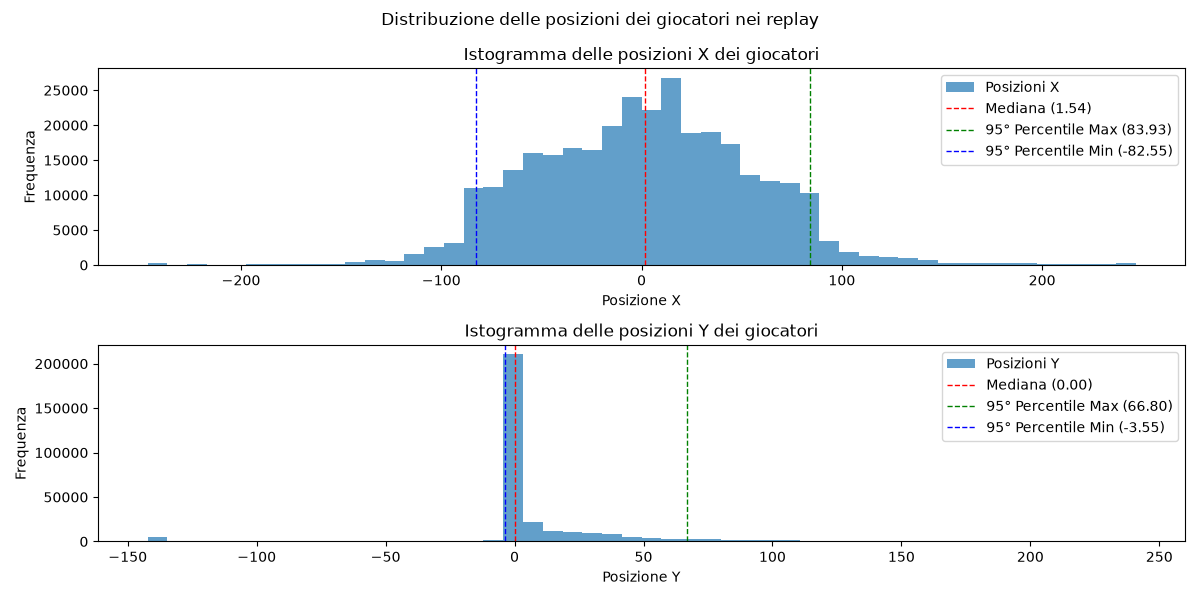

In [8]:
plt.figure(figsize=(12, 6))

plt.suptitle("Distribuzione delle posizioni dei giocatori nei replay")

plt.subplot(2, 1, 1)

plt.title("Istogramma delle posizioni X dei giocatori")

x_pos = []
for s in sessions:
    for port in s.ports:
        x_pos.extend(s.all_positions(port)[0])

x_pos = np.array(x_pos)

x_median = np.median(x_pos)
x_95_max = np.percentile(x_pos, 95)
x_95_min = np.percentile(x_pos, 5)

plt.hist(x_pos, bins=50, alpha=0.7, label="Posizioni X", density=False)

plt.axvline(x_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({x_median:.2f})')
plt.axvline(x_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({x_95_max:.2f})')
plt.axvline(x_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({x_95_min:.2f})')

plt.xlabel("Posizione X")
plt.ylabel("Frequenza")
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Istogramma delle posizioni Y dei giocatori")

y_pos = []
for s in sessions:
    for port in s.ports:
        y_pos.extend(s.all_positions(port)[1])

y_pos = np.array(y_pos)
y_median = np.median(y_pos)
y_95_max = np.percentile(y_pos, 95)
y_95_min = np.percentile(y_pos, 5)

plt.hist(y_pos, bins=50, alpha=0.7, label="Posizioni Y", density=False)

plt.axvline(y_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({y_median:.2f})')
plt.axvline(y_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({y_95_max:.2f})')
plt.axvline(y_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({y_95_min:.2f})')

plt.xlabel("Posizione Y")
plt.ylabel("Frequenza")
plt.legend()

plt.tight_layout()
plt.show()


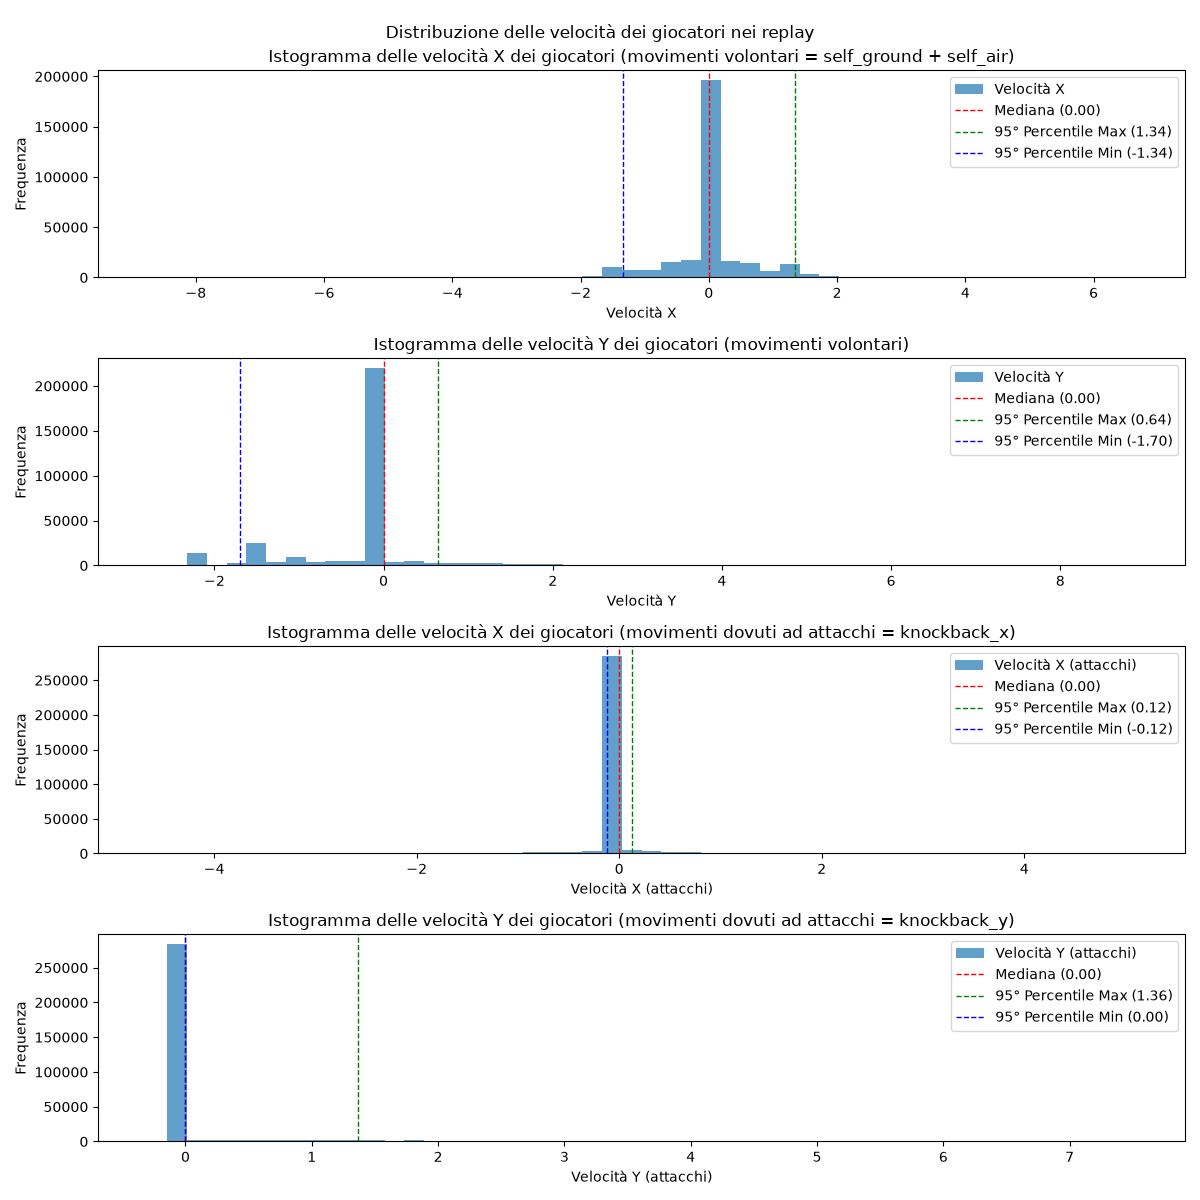

In [9]:
plt.figure(figsize=(12, 12))

plt.suptitle("Distribuzione delle velocità dei giocatori nei replay")

plt.subplot(4, 1, 1)

plt.title("Istogramma delle velocità X dei giocatori (movimenti volontari = self_ground + self_air)")

x_vel = []
for s in sessions:
    for port in s.ports:
        x_vel.extend(s.all_velocities(port)[0])

x_vel = np.array(x_vel)
x_vel_median = np.median(x_vel)
x_vel_95_max = np.percentile(x_vel, 95)
x_vel_95_min = np.percentile(x_vel, 5)

plt.hist(x_vel, bins=50, alpha=0.7, label="Velocità X", density=False)
plt.axvline(x_vel_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({x_vel_median:.2f})')
plt.axvline(x_vel_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({x_vel_95_max:.2f})')
plt.axvline(x_vel_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({x_vel_95_min:.2f})')

plt.xlabel("Velocità X")
plt.ylabel("Frequenza")
plt.legend()

plt.subplot(4, 1, 2)
plt.title("Istogramma delle velocità Y dei giocatori (movimenti volontari)")

y_vel = []
for s in sessions:
    for port in s.ports:
        y_vel.extend(s.all_velocities(port)[1])
y_vel = np.array(y_vel)
y_vel_median = np.median(y_vel)
y_vel_95_max = np.percentile(y_vel, 95)
y_vel_95_min = np.percentile(y_vel, 5)

plt.hist(y_vel, bins=50, alpha=0.7, label="Velocità Y", density=False)
plt.axvline(y_vel_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({y_vel_median:.2f})')
plt.axvline(y_vel_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({y_vel_95_max:.2f})')
plt.axvline(y_vel_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({y_vel_95_min:.2f})')

plt.xlabel("Velocità Y")
plt.ylabel("Frequenza")
plt.legend()

plt.subplot(4, 1, 3)
plt.title("Istogramma delle velocità X dei giocatori (movimenti dovuti ad attacchi = knockback_x)")

x_vel_attack = []
for s in sessions:
    for port in s.ports:
        x_vel_attack.extend(s.all_velocities(port)[2])
x_vel_attack = np.array(x_vel_attack)
x_vel_attack_median = np.median(x_vel_attack)
x_vel_attack_95_max = np.percentile(x_vel_attack, 95)
x_vel_attack_95_min = np.percentile(x_vel_attack, 5)

plt.hist(x_vel_attack, bins=50, alpha=0.7, label="Velocità X (attacchi)", density=False)
plt.axvline(x_vel_attack_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({x_vel_attack_median:.2f})')
plt.axvline(x_vel_attack_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({x_vel_attack_95_max:.2f})')
plt.axvline(x_vel_attack_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({x_vel_attack_95_min:.2f})')

plt.xlabel("Velocità X (attacchi)")
plt.ylabel("Frequenza")
plt.legend()

plt.subplot(4, 1, 4)
plt.title("Istogramma delle velocità Y dei giocatori (movimenti dovuti ad attacchi = knockback_y)")
y_vel_attack = []
for s in sessions:
    for port in s.ports:
        y_vel_attack.extend(s.all_velocities(port)[3])
y_vel_attack = np.array(y_vel_attack)
y_vel_attack_median = np.median(y_vel_attack)
y_vel_attack_95_max = np.percentile(y_vel_attack, 95)
y_vel_attack_95_min = np.percentile(y_vel_attack, 5)

plt.hist(y_vel_attack, bins=50, alpha=0.7, label="Velocità Y (attacchi)", density=False)
plt.axvline(y_vel_attack_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({y_vel_attack_median:.2f})')
plt.axvline(y_vel_attack_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({y_vel_attack_95_max:.2f})')
plt.axvline(y_vel_attack_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({y_vel_attack_95_min:.2f})')
plt.xlabel("Velocità Y (attacchi)")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.show()


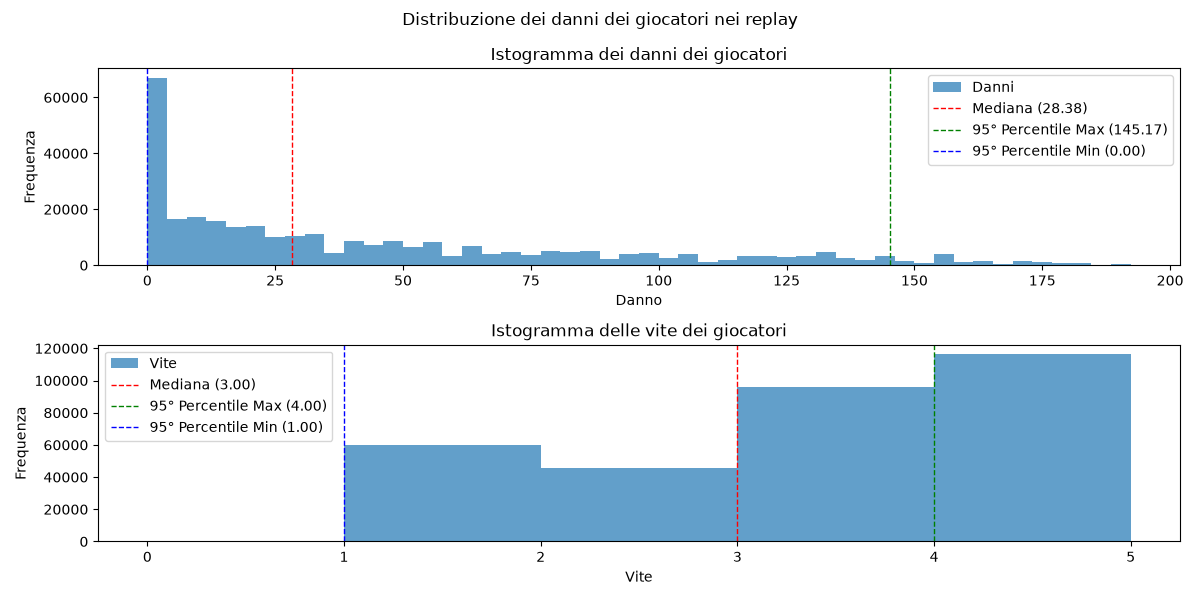

In [10]:
plt.figure(figsize=(12, 6))

plt.suptitle("Distribuzione dei danni dei giocatori nei replay")

plt.subplot(2, 1, 1)
plt.title("Istogramma dei danni dei giocatori")

percents = []
for s in sessions:
    for port in s.ports:
        percents.extend(s.all_percents(port))
percents = np.array(percents)
percents_median = np.median(percents)
percents_95_max = np.percentile(percents, 95)
percents_95_min = np.percentile(percents, 5)

plt.hist(percents, bins=50, alpha=0.7, label="Danni", density=False)
plt.axvline(percents_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({percents_median:.2f})')
plt.axvline(percents_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({percents_95_max:.2f})')
plt.axvline(percents_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({percents_95_min:.2f})')
plt.xlabel("Danno")
plt.ylabel("Frequenza")
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Istogramma delle vite dei giocatori")

stocks = []
for s in sessions:
    for port in s.ports:
        stocks.extend(s.all_stocks(port))
stocks = np.array(stocks)
stocks_median = np.median(stocks)
stocks_95_max = np.percentile(stocks, 95)
stocks_95_min = np.percentile(stocks, 5)

plt.hist(stocks, bins=range(int(stocks.min()), int(stocks.max()) + 2), alpha=0.7, label="Vite", density=False)
plt.axvline(stocks_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({stocks_median:.2f})')
plt.axvline(stocks_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({stocks_95_max:.2f})')
plt.axvline(stocks_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({stocks_95_min:.2f})')
plt.xlabel("Vite")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.show()


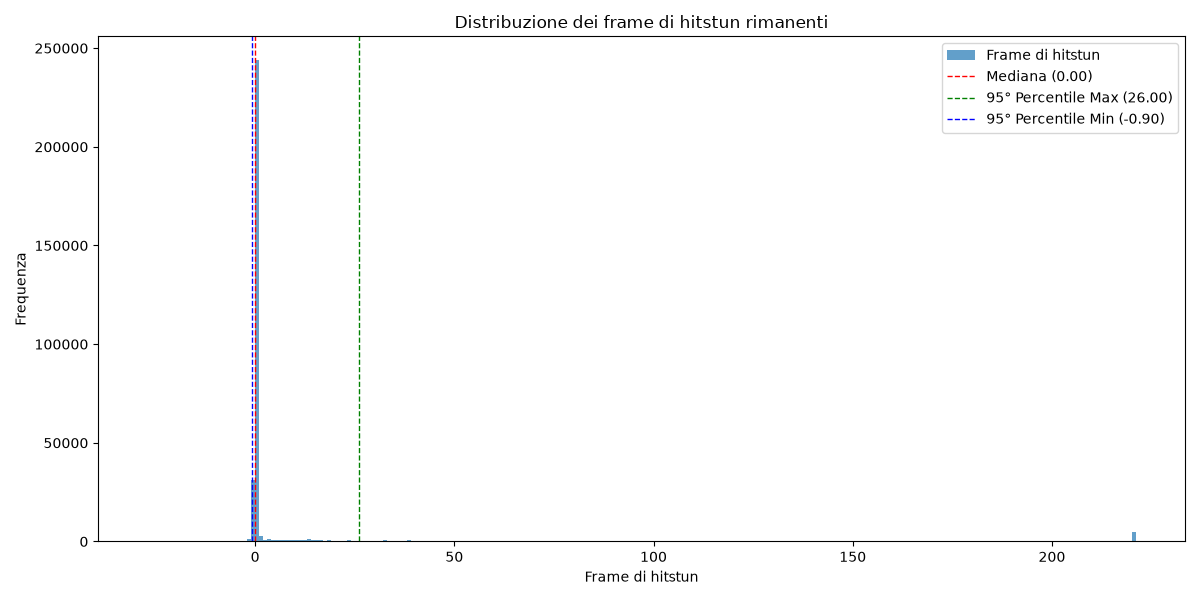

In [11]:
# frame di hitstun

plt.figure(figsize=(12, 6))

plt.title("Distribuzione dei frame di hitstun rimanenti")
hitstun_frames = []
for s in sessions:
    for port in s.ports:
        hitstun_frames.extend(s.all_hitstun_frames(port))
hitstun_frames = np.array(hitstun_frames)
hitstun_median = np.median(hitstun_frames)
hitstun_95_max = np.percentile(hitstun_frames, 95)
hitstun_95_min = np.percentile(hitstun_frames, 5)

plt.hist(hitstun_frames, bins=range(int(hitstun_frames.min()), int(hitstun_frames.max()) + 2), alpha=0.7, label="Frame di hitstun", density=False)
plt.axvline(hitstun_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({hitstun_median:.2f})')
plt.axvline(hitstun_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({hitstun_95_max:.2f})')
plt.axvline(hitstun_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({hitstun_95_min:.2f})')
plt.xlabel("Frame di hitstun")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.show()



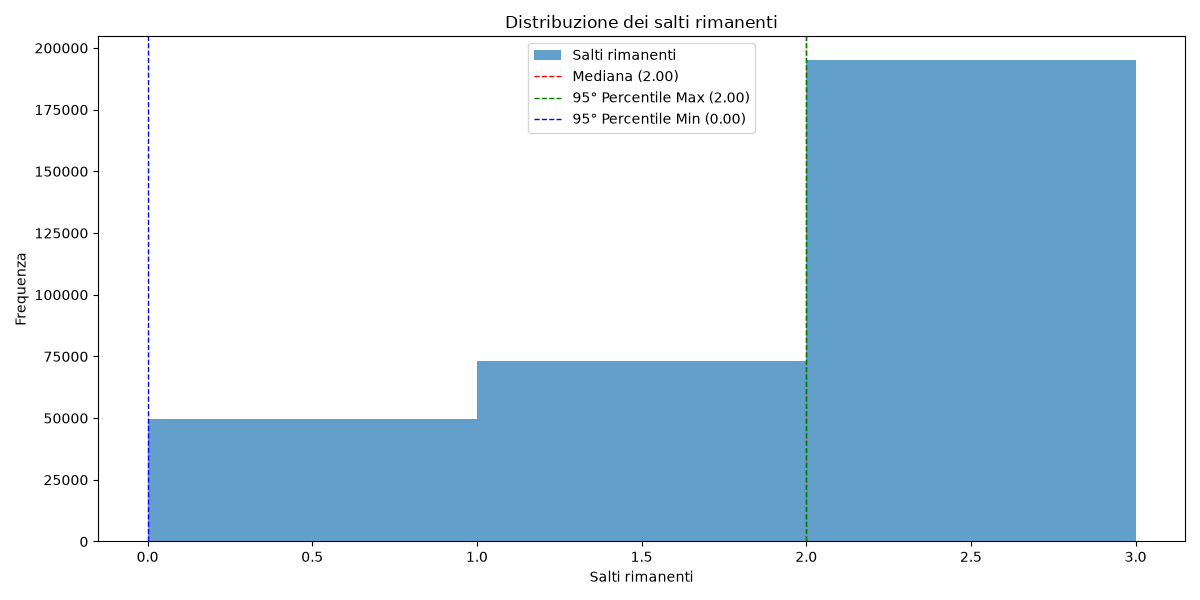

In [12]:
# salti rimanenti
plt.figure(figsize=(12, 6))
plt.title("Distribuzione dei salti rimanenti")
jumps_remaining = []
for s in sessions:
    for port in s.ports:
        jumps_remaining.extend(s.all_jumps_remaining(port))
jumps_remaining = np.array(jumps_remaining)
jumps_median = np.median(jumps_remaining)
jumps_95_max = np.percentile(jumps_remaining, 95)
jumps_95_min = np.percentile(jumps_remaining, 5)

plt.hist(jumps_remaining, bins=range(int(jumps_remaining.min()), int(jumps_remaining.max()) + 2), alpha=0.7, label="Salti rimanenti", density=False)
plt.axvline(jumps_median, color='r', linestyle='dashed', linewidth=1, label=f'Mediana ({jumps_median:.2f})')
plt.axvline(jumps_95_max, color='g', linestyle='dashed', linewidth=1, label=f'95° Percentile Max ({jumps_95_max:.2f})')
plt.axvline(jumps_95_min, color='b', linestyle='dashed', linewidth=1, label=f'95° Percentile Min ({jumps_95_min:.2f})')
plt.xlabel("Salti rimanenti")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.show()